In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.mixture import GaussianMixture
from collections import defaultdict
import seaborn as sns


# Oppgave 1

We begin by loading the necessary data. A function is created to read the labels (vowels) and features, storing them in a dictionary. Finally, we split the data into training and test sets.

In [3]:
def load_vowel_data(filename):
    vowel_data = {}

    with open(filename, "r") as file:
        for line in file:
            parts = line.split()
            label = parts[0][-2:]  #extrct vocal, for example in m01ae is ae the vocal. The last two is always the vocal
            features = parts[2:5]  # the features are the 3rd to 6th element in the line 
            features = [int(f) for f in features]  # convert to float
            print(features)
            if label not in vowel_data:
                vowel_data[label] = []
            vowel_data[label].append(features)

    
    for vowel in vowel_data:
        vowel_data[vowel] = np.array(vowel_data[vowel])
    
    return vowel_data

# load data from file
filename = 'Data/Iris_TTT4275/vowdata_nohead.dat'
vowel_data = load_vowel_data(filename)

# Splitt into trainingset (first 70 samples) og testset (last 69 samples)
train_data = {vowel: data[:70] for vowel, data in vowel_data.items()}
test_data = {vowel: data[70:] for vowel, data in vowel_data.items()}



[174, 663, 2012]
[102, 628, 1871]
[99, 605, 1812]
[124, 627, 1910]
[115, 647, 1864]
[96, 582, 1999]
[122, 602, 1880]
[120, 545, 1872]
[153, 552, 2027]
[136, 629, 1871]
[100, 685, 1807]
[106, 559, 1983]
[138, 544, 1819]
[135, 685, 1592]
[133, 514, 2031]
[149, 612, 1937]
[140, 544, 2114]
[108, 556, 1854]
[119, 619, 2023]
[112, 601, 1997]
[120, 572, 2072]
[115, 546, 1820]
[120, 562, 1895]
[105, 594, 2000]
[131, 662, 1934]
[114, 566, 2041]
[96, 559, 1873]
[143, 579, 1982]
[149, 623, 1937]
[136, 555, 1996]
[129, 555, 1849]
[110, 634, 1730]
[121, 570, 1856]
[130, 614, 1768]
[131, 553, 2140]
[153, 605, 2002]
[140, 597, 1989]
[139, 561, 1772]
[128, 615, 1885]
[98, 577, 1952]
[187, 629, 2436]
[129, 511, 1811]
[119, 590, 1830]
[123, 622, 1957]
[116, 565, 2055]
[225, 678, 2293]
[214, 624, 2442]
[192, 666, 2370]
[233, 743, 2230]
[223, 677, 2320]
[223, 627, 2266]
[176, 690, 2327]
[238, 658, 2650]
[251, 685, 2299]
[227, 621, 2249]
[188, 868, 2004]
[229, 682, 2486]
[237, 668, 2252]
[214, 726, 2350]
[

Then we will find the mean value for each feature for each class and full covariance matrix for each class

In [4]:
# function to compute mean value and covariance matrix
def compute_mean_covariance(data):
    mean_vectors = {}
    covariance_matrices = {}

    for vowel, samples in data.items():
        mean_vectors[vowel] = np.mean(samples, axis=0)  # find mean for each vowel and store in mean_vectores
        covariance_matrices[vowel] = np.cov(samples, rowvar=False)  # find covariance matrix for each vowel
    return mean_vectors, covariance_matrices

# Use the function above to find mean value and covarance matrix for each vowel in training set
mean_vectors, covariance_matrices = compute_mean_covariance(train_data)


for vowel in mean_vectors:
    print(f"\nVokal: {vowel}")
    print(f"Middelverdi: {mean_vectors[vowel]}")
    print(f"Kovariansmatrise:\n{covariance_matrices[vowel]}")




Vokal: ae
Middelverdi: [ 157.84285714  620.48571429 2066.55714286]
Kovariansmatrise:
[[ 2284.16335404  1736.75859213  9009.37867495]
 [ 1736.75859213  3955.44182195  5103.69648033]
 [ 9009.37867495  5103.69648033 53592.91697723]]

Vokal: ah
Middelverdi: [ 156.82857143  814.01428571 1388.28571429]
Kovariansmatrise:
[[ 2101.47743271  3162.81407867  4739.42650104]
 [ 3162.81407867 11336.21718427 11346.30020704]
 [ 4739.42650104 11346.30020704 25913.91718427]]

Vokal: aw
Middelverdi: [ 156.85714286  706.04285714 1087.9       ]
Kovariansmatrise:
[[ 2260.21118012  3217.16563147  4389.92753623]
 [ 3217.16563147  7057.89668737  8109.01884058]
 [ 4389.92753623  8109.01884058 15766.26521739]]

Vokal: eh
Middelverdi: [ 158.57142857  637.91428571 1895.45714286]
Kovariansmatrise:
[[ 2227.78467909  3320.64389234  5427.47412008]
 [ 3320.64389234  7472.31138716  8825.85134576]
 [ 5427.47412008  8825.85134576 30626.62857143]]

Vokal: ei
Middelverdi: [ 161.92857143  501.07142857 2243.18571429]
Kovarian

Function to classify a sample with a single Gaussian class model.

The classification is based on Gaussian density: 

$$
p(x / \omega_i) = N(\mu_i, \Sigma_i) = \frac{1}{\sqrt{(2\pi)^D |\Sigma_i|}} \exp \left[ -\frac{1}{2} (x - \mu_i)^T \Sigma_i^{-1} (x - \mu_i) \right], \quad i = 1, \dots, C
$$

For each sample, we calculate the probability that it belongs to a certain class and assign it to the class with the highest likelihood.


In [5]:
def classify_sample(x, mean_vectors, cov_matrices):
    best_class = None   # Our goal is to find the best class, this will be updated if probability of this class is better than all the earlier classes
    max_prob = -np.inf  #set as low as possible, updates later. 
    
    for vowel, mean in mean_vectors.items():
        cov = cov_matrices[vowel] 
        det_cov = np.linalg.det(cov)
        cov_inv = np.linalg.inv(cov)
        
        #PDF
        diff = x - mean
        exponent = -0.5 * np.dot(diff.T, np.dot(cov_inv, diff))
        prob = np.exp(exponent) / np.sqrt((2 * np.pi) ** 3 * det_cov) 

        if prob > max_prob:
            max_prob = prob
            best_class = vowel

    return best_class


Than we use the classifier on the samples in test data and compute the error rate and plot confusionmatrix.

Feilrate: 34.18%


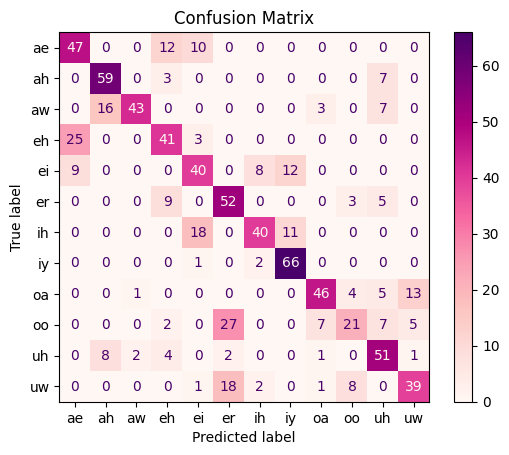

In [6]:
true_labels = []
predicted_labels = []

for vowel, samples in test_data.items():
    for sample in samples:
        predicted_vowel = classify_sample(sample, mean_vectors, covariance_matrices)
        true_labels.append(vowel)
        predicted_labels.append(predicted_vowel)
        
# Make confusion matrix and error rate to analyse the clasifier
conf_matrix = confusion_matrix(true_labels, predicted_labels, labels=list(vowel_data.keys()))
error_rate = 1 - accuracy_score(true_labels, predicted_labels)

# Bruke ConfusionMatrixDisplay 
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=vowel_data.keys())
disp.plot(cmap="RdPu")  # Fungerer i Blues også
plt.title("Confusion Matrix")
print(f"Feilrate: {error_rate*100:.2f}%")
plt.show()
#print(true_labels)
#print(predicted_labels)

Make diagonal covariance matrix by multiplying with the identity matrix

In [7]:
diag_cov_matrices = {}

for vowel in mean_vectors:
    identity_matrix = np.identity(3)
    diag_cov_matrices[vowel] = covariance_matrices[vowel]*identity_matrix
    #print(f'Diagonal matrix for {vowel}:\n {diag_cov_matrices[vowel]}\n ')



Classify the samples with diagonal covariance matrix. Than make confusion matrix and error rate.

Feilrate: 53.86%


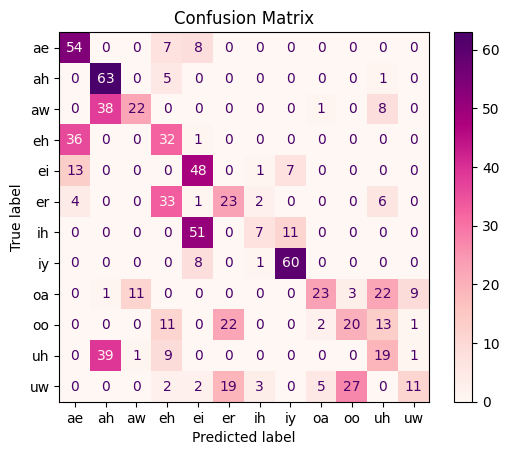

In [8]:
predicted_labels_diag = []

for vowel, samples in test_data.items():
    for sample in samples:
        predicted_vowel = classify_sample(sample, mean_vectors, diag_cov_matrices)
        predicted_labels_diag.append(predicted_vowel)

conf_matrix_diag = confusion_matrix(true_labels, predicted_labels_diag, labels=list(vowel_data.keys()))
error_rate_diag = 1 - accuracy_score(true_labels, predicted_labels_diag)

# Bruke ConfusionMatrixDisplay 
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_diag, display_labels=test_data.keys())
disp.plot(cmap="RdPu")  # Fungerer i Blues også
plt.title("Confusion Matrix")
print(f"Feilrate: {error_rate_diag*100:.2f}%")
plt.show()

Dårligere, gir mening siden vi kun bruker diagonalen av covariansmartrisen, som er det samme som å anta uavhengighet mellom featurene. Det er vel litt naivt...

Er det kanskje litt vel dårlig?


# Oppgave 2

Function to train GMM models

In [9]:
def train_gmm_models(train_data, n_components):
    gmm_models = {}
    
    for vowel, samples in train_data.items():
        gmm = GaussianMixture(n_components=n_components, covariance_type='diag', random_state=42)
        gmm.fit(samples)
        gmm_models[vowel] = gmm
    
    return gmm_models 

Function to classify a sample with the GMM model

In [10]:
def classify_sample_gmm(sample, gmm_models):
    max_log_likelihood = -np.inf 
    best_class = None 
    
    for vowel, gmm in gmm_models.items():
        log_likelihood = gmm.score_samples(sample.reshape(1, -1))[0] #skjønner ikke helt shapinga
        
        if log_likelihood > max_log_likelihood:
            max_log_likelihood = log_likelihood
            best_class = vowel
    
    return best_class

Functon that can be used on GMMs that compute confusion matrix and error rate. 

In [11]:
def evaluate_classifier(test_data, gmm_models):
    true_labels = []
    predicted_labels = []
    
    for vowel, samples in test_data.items():
        for sample in samples:
            predicted_vowel = classify_sample_gmm(sample, gmm_models)
            true_labels.append(vowel)
            predicted_labels.append(predicted_vowel)
    
    conf_matrix = confusion_matrix(true_labels, predicted_labels, labels=list(test_data.keys()))
    error_rate = 1 - accuracy_score(true_labels, predicted_labels)
    
    return conf_matrix, error_rate


Feilrate: 37.80


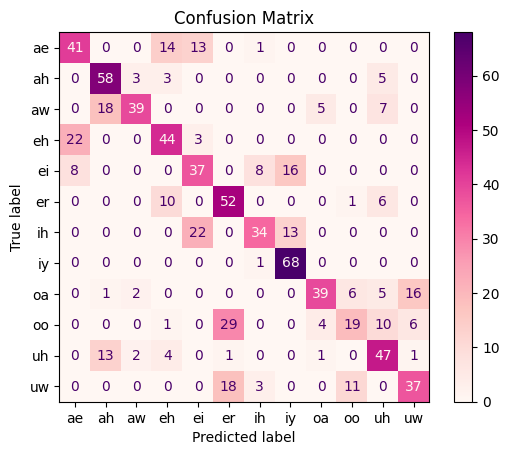

Feilrate: 36.23


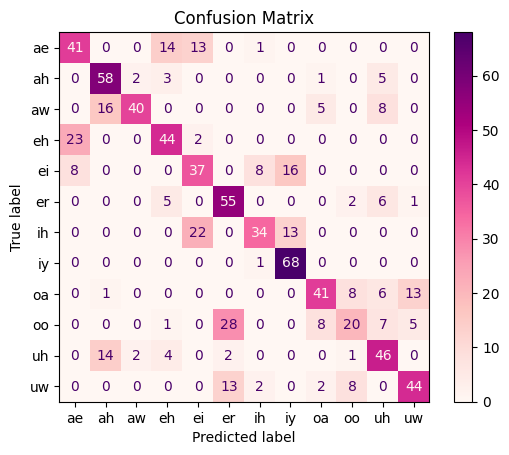

In [12]:

# Train GMM models (for 2 and 3)
gmm_models_2 = train_gmm_models(train_data, n_components=2)
gmm_models_3 = train_gmm_models(train_data, n_components=3)

# Evaluate classifiers
conf_matrix_2, error_rate_2 = evaluate_classifier(test_data, gmm_models_2)
conf_matrix_3, error_rate_3 = evaluate_classifier(test_data, gmm_models_3)

print(f"Feilrate: {error_rate_2*100:.2f}")

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_2, display_labels=test_data.keys())
disp.plot(cmap="RdPu")  # Fungerer i Blues også
plt.title("Confusion Matrix")
plt.show()

print(f"Feilrate: {error_rate_3*100:.2f}")

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_3, display_labels=test_data.keys())
disp.plot(cmap="RdPu")  # Fungerer i Blues også
plt.title("Confusion Matrix")
plt.show()


**(d) Compare the performances for all four model types (tasks 1b, 1c and 2c). For
which class(es) is the difference largest?**

- Ser at det er best performance for GMM 3 blandt de med kun diagonal, men ikke så stor forskjell fra GMM 2
- Vanlig full covarians er best, kan se for full covarian på de to siste om det blir bedre?
- GMM2 er best på de første, gmm 3 er best på de siste
- Må vel sammenligne mer nøye

Feilrate: 34.06


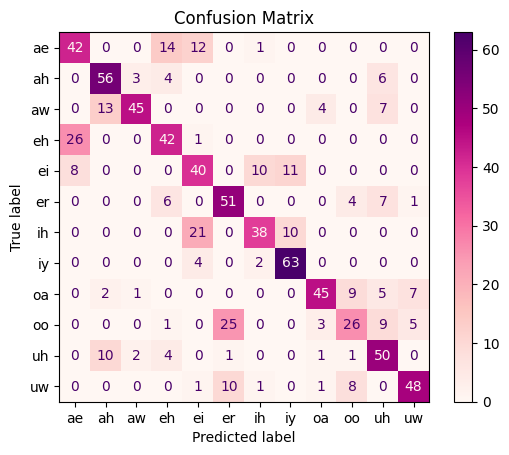

Feilrate: 37.68


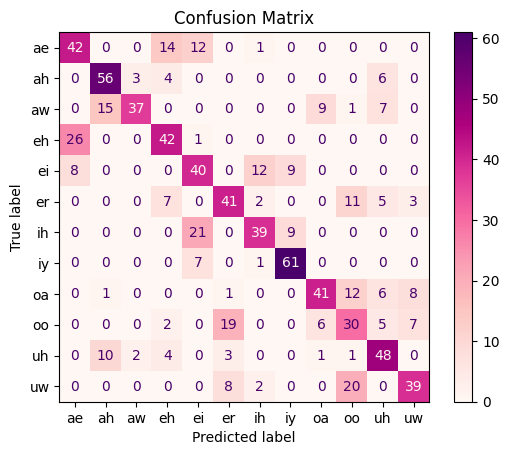

In [13]:
#Setter full covariansmatriser

def train_gmm_models_full(train_data, n_components):
    gmm_models = {}
    
    for vowel, samples in train_data.items():
        gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
        gmm.fit(samples)
        gmm_models[vowel] = gmm
    
    return gmm_models 

# Tren GMM-modeller med 2 og 3 komponenter
gmm_models_2 = train_gmm_models_full(train_data, n_components=2)
gmm_models_3 = train_gmm_models_full(train_data, n_components=3)

# Evaluere modellene, 2 og 2 gmm
conf_matrix_2, error_rate_2 = evaluate_classifier(test_data, gmm_models_2)
conf_matrix_3, error_rate_3 = evaluate_classifier(test_data, gmm_models_3)

print(f"Feilrate: {error_rate_2*100:.2f}")

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_2, display_labels=test_data.keys())
disp.plot(cmap="RdPu")  # Fungerer i Blues også
plt.title("Confusion Matrix")
plt.show()


print(f"Feilrate: {error_rate_3*100:.2f}")

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_3, display_labels=test_data.keys())
disp.plot(cmap="RdPu")  # Fungerer i Blues også
plt.title("Confusion Matrix")
plt.show()


Definitivt best, men usikker på om dette er del av oppgaven... Men her er plutselig 2 bedre enn 3

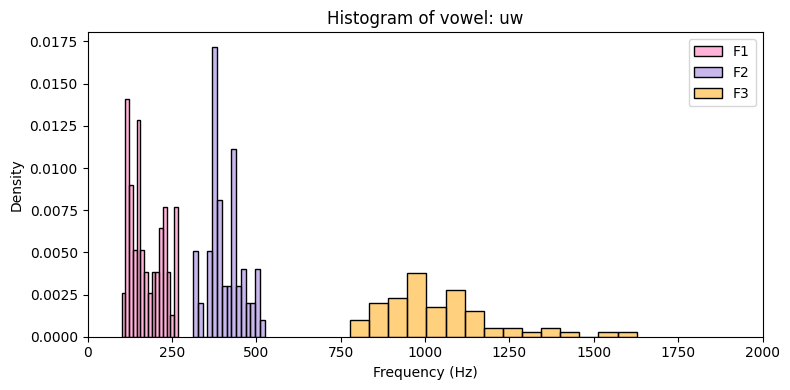

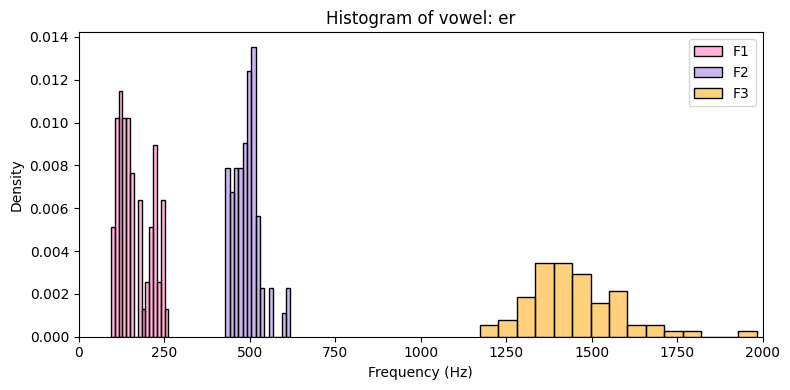

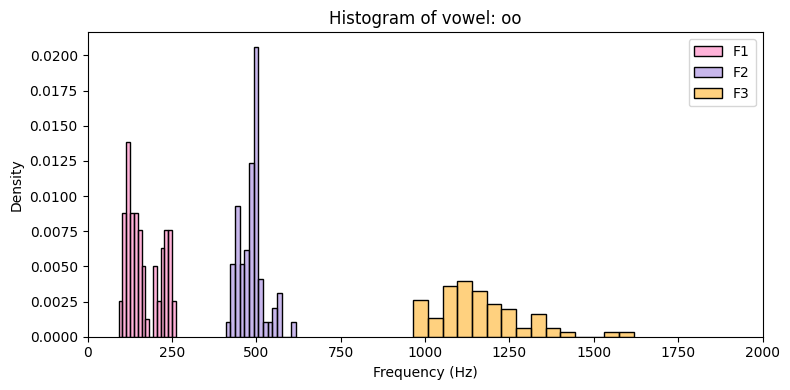

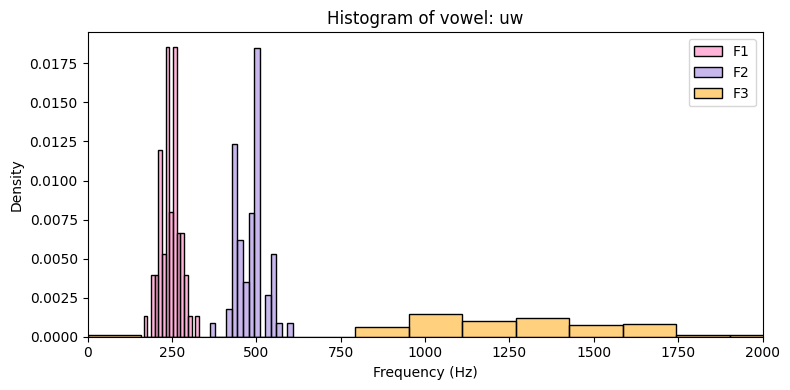

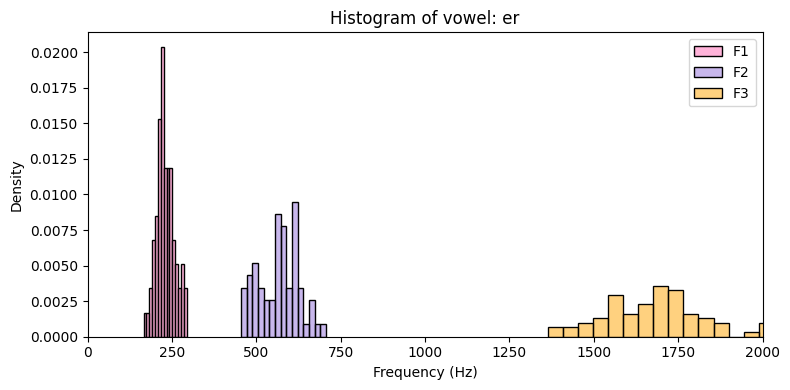

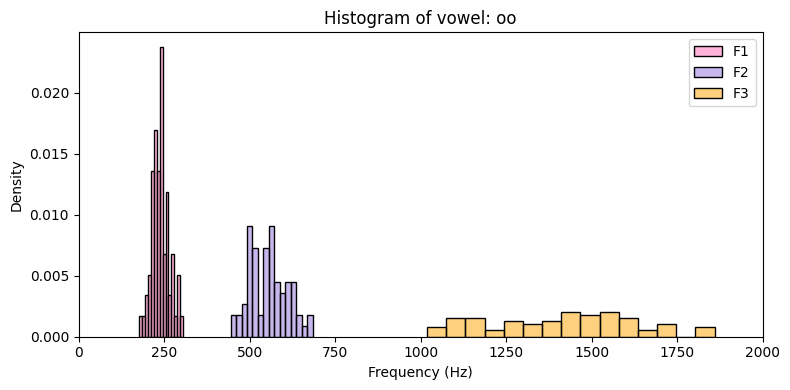

In [19]:
def print_vowel_histograms(train_data, selected_vowels):
    colors = {
        'F1': 'hotpink',
        'F2': 'mediumpurple',
        'F3': 'orange'
    }  # Farger for hver formant
    
    for vowel in selected_vowels & train_data.keys():
        formant_values = np.array(train_data[vowel])
        formant_data = {"F1": formant_values[:, 0], "F2": formant_values[:, 1], "F3": formant_values[:, 2]}

        plt.figure(figsize=(8, 4))
        for formant, values in formant_data.items():
            sns.histplot(values, bins=15, color=colors[formant], stat="density", alpha=0.5, label=formant)

        plt.title(f'Histogram of vowel: {vowel}')
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Density')
        plt.xlim(0, 2000)
        plt.legend()
        plt.tight_layout()
        plt.show()

# Kjør funksjonen
print_vowel_histograms(train_data, {"oo", "er", "uw"})
print_vowel_histograms(test_data, {"oo", "er", "uw"})


Første to features er ganske like, derfor den gjør mye feil?


Forvirringsmatrise (full kovarians):
[[49  0  0 13  7  0  0  0  0  0  0  0]
 [ 0 55  1  0  0  0  0  0  0  0 13  0]
 [ 0  7 55  0  0  0  0  0  0  0  7  0]
 [22  1  0 45  1  0  0  0  0  0  0  0]
 [ 4  0  0  0 42  0 19  4  0  0  0  0]
 [ 0  0  0  2  0 61  2  0  0  4  0  0]
 [ 0  0  0  0 12  0 49  8  0  0  0  0]
 [ 0  0  0  0  3  0  2 64  0  0  0  0]
 [ 0  0  1  0  0  0  0  0 47  4  5 12]
 [ 0  0  0  1  0  9  0  0  5 50  1  3]
 [ 0  2  2  0  0  0  0  0  1  0 63  1]
 [ 0  0  0  0  1  5  0  0  1  3  0 59]]
Feilrate: 22.83%
Forvirringsmatrise (GMM, 2 komponenter):
[[29  0  0 19 20  0  1  0  0  0  0  0]
 [ 0 51  2  2  0  0  0  0  0  0 14  0]
 [ 0  5 46  0  0  0  0  0  5  2 11  0]
 [15  1  0 44  9  0  0  0  0  0  0  0]
 [ 0  0  0  0 44  0 18  7  0  0  0  0]
 [ 0  0  0  6  0 48  3  0  0  9  3  0]
 [ 0  0  0  0 21  0 43  5  0  0  0  0]
 [ 0  0  0  0  1  0  5 63  0  0  0  0]
 [ 0  0  1  0  0  0  0  0 48  5  3 12]
 [ 0  0  0  1  0  6  0  0  5 52  2  3]
 [ 0  8  6  0  0  1  0  0  0  1 53  0]
 [ 0  0

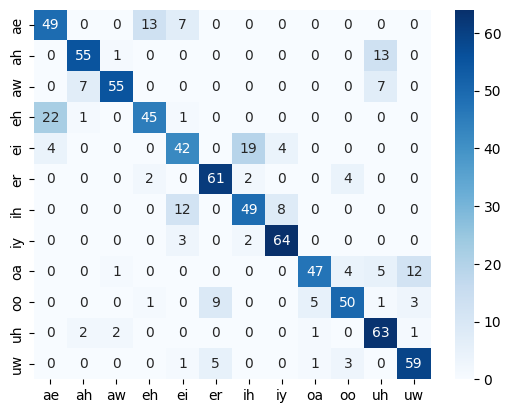

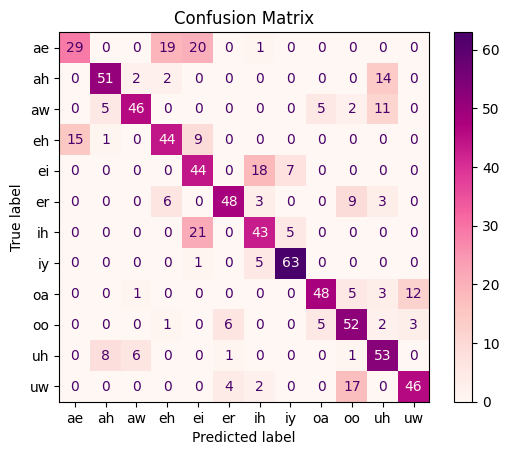


Forvirringsmatrise (GMM, 3 komponenter):
[[28  0  0 13 27  0  1  0  0  0  0  0]
 [ 0 49  2  2  0  0  0  0  0  0 16  0]
 [ 0  5 49  0  0  0  0  0  0  2 13  0]
 [12  1  0 48  8  0  0  0  0  0  0  0]
 [ 0  0  0  0 46  0 16  7  0  0  0  0]
 [ 0  0  0  5  0 43  3  0  0 13  3  2]
 [ 0  0  0  0 18  0 46  5  0  0  0  0]
 [ 0  0  0  0  1  0  3 65  0  0  0  0]
 [ 0  0  2  0  0  0  0  0 42  8  5 12]
 [ 0  0  0  1  0  0  0  0  9 55  4  0]
 [ 0  8  9  0  0  1  0  0  0  1 50  0]
 [ 0  0  0  0  0  2  2  0 12  7  0 46]]
Feilrate: 31.52


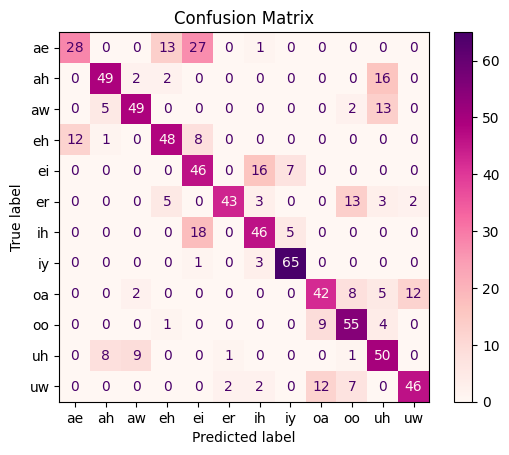

In [ ]:
#lager randome rekkefølge
import random

for vowel in vowel_data:
        random.shuffle(vowel_data[vowel])  # Shuffle data randomly
        vowel_data[vowel] = np.array(vowel_data[vowel])


# Split into training set (first 70 samples) and test set (remaining samples)
train_data = {vowel: data[:70] for vowel, data in vowel_data.items()}
test_data = {vowel: data[70:] for vowel, data in vowel_data.items()}

true_labels = []
predicted_labels = []

for vowel, samples in test_data.items():
    for sample in samples:
        predicted_vowel = classify_sample(sample, mean_vectors, covariance_matrices)
        true_labels.append(vowel)
        predicted_labels.append(predicted_vowel)
        
# Make confusion matrix and error rate to analyse the clasifier
conf_matrix = confusion_matrix(true_labels, predicted_labels, labels=list(vowel_data.keys()))
error_rate = 1 - accuracy_score(true_labels, predicted_labels)


#Usikker på hvilken stil:)
#eksempel på en litt finere fremstilling
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=test_data.keys(), yticklabels=test_data.keys())

print("Forvirringsmatrise (full kovarians):")
print(conf_matrix)
print(f"Feilrate: {error_rate*100:.2f}%")

# Train GMM models (for 2 and 3)
gmm_models_2 = train_gmm_models(train_data, n_components=2)
gmm_models_3 = train_gmm_models(train_data, n_components=3)

# Evaluate classifiers
conf_matrix_2, error_rate_2 = evaluate_classifier(test_data, gmm_models_2)
conf_matrix_3, error_rate_3 = evaluate_classifier(test_data, gmm_models_3)

#print, fix format later:)
print("Forvirringsmatrise (GMM, 2 komponenter):")
print(conf_matrix_2)
print(f"Feilrate: {error_rate_2*100:.2f}")

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_2, display_labels=test_data.keys())
disp.plot(cmap="RdPu")  # Fungerer i Blues også
plt.title("Confusion Matrix")
plt.show()

print("\nForvirringsmatrise (GMM, 3 komponenter):")
print(conf_matrix_3)
print(f"Feilrate: {error_rate_3*100:.2f}")

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_3, display_labels=test_data.keys())
disp.plot(cmap="RdPu")  # Fungerer i Blues også
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# Velg hvilke vokaler du vil plotte
import numpy as np
import matplotlib.pyplot as plt

# Velg hvilke vokaler du vil plotte
#selected_vowels = {"ae", "ih", "ei"}  # Endre dette etter behov
colors = {"F1": "red", "F2": "blue", "F3": "green"}  
"""
for vowel in train_data.keys(): #selected_vowels & 
    formant_values = np.array(train_data[vowel])  
    formant_data = {"F1": formant_values[:, 0], "F2": formant_values[:, 1], "F3": formant_values[:, 2]}

    plt.figure(figsize=(6, 4))
    for formant, values in formant_data.items():
        plt.hist(values, bins=15, color=colors[formant], alpha=0.6, label=formant, edgecolor="black")

    plt.xlabel("Frekvens (Hz)")
    plt.xlim(0,3100)
    plt.ylabel("Antall forekomster")
    plt.title(f"Vokal: {vowel}")
    plt.legend()
    plt.show()"""


'\nfor vowel in train_data.keys(): #selected_vowels & \n    formant_values = np.array(train_data[vowel])  \n    formant_data = {"F1": formant_values[:, 0], "F2": formant_values[:, 1], "F3": formant_values[:, 2]}\n\n    plt.figure(figsize=(6, 4))\n    for formant, values in formant_data.items():\n        plt.hist(values, bins=15, color=colors[formant], alpha=0.6, label=formant, edgecolor="black")\n\n    plt.xlabel("Frekvens (Hz)")\n    plt.xlim(0,3100)\n    plt.ylabel("Antall forekomster")\n    plt.title(f"Vokal: {vowel}")\n    plt.legend()\n    plt.show()'